<a href="https://colab.research.google.com/github/lsingh25-bit/KernelCraft/blob/main/KernelCraft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

%%writefile phase1.cu
#include <iostream>
#include <cuda_runtime.h>
#include <chrono>
using namespace std;

void ConstAddCPU(const unsigned char* input, unsigned char* output, int N) {
    for (int i = 0; i < N; i++) {
        output[i] = input[i] + 2;
    }
}

__global__ void ConstAdd(const unsigned char* d_input, unsigned char* d_output, int N){
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N){
        d_output[idx] = d_input[idx] + 2;
    }
}

int main(){
    int N = 1000000;
    size_t size = N * sizeof(unsigned char);
    unsigned char *h_input, *h_output;
    unsigned char *d_input, *d_output;

    h_input = (unsigned char*)malloc(size);
    h_output = (unsigned char*)malloc(size);
    for (int i=0; i<N; i++){
        h_input[i] = 100;
    }

    // CPU Execution & Timing
    auto cpu_start = chrono::high_resolution_clock::now();
    ConstAddCPU(h_input, h_output, N);
    auto cpu_end = chrono::high_resolution_clock::now();
    auto cpu_time = chrono::duration_cast<chrono::microseconds>(cpu_end - cpu_start);
    cout << "CPU Time: " << cpu_time.count() << " microseconds" << endl;

    // GPU Allocation
    cudaMalloc((void**)&d_input, size);
    cudaMalloc((void**)&d_output, size);

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    // Start GPU Timing
    cudaEventRecord(start, 0);

    cudaMemcpy(d_input, h_input, size, cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (N + threads - 1) / threads;
    ConstAdd<<<blocks, threads>>>(d_input, d_output, N);

    cudaMemcpy(h_output, d_output, size, cudaMemcpyDeviceToHost);

    // FIX: Stop GPU Timing right after data comes back (before printing)
    cudaEventRecord(stop, 0);
    cudaEventSynchronize(stop);

    float milliseconds = 0;
    cudaEventElapsedTime(&milliseconds, start, stop);



    cout << "GPU Time (including Memcpy): " << milliseconds << " milliseconds" << endl;

    cudaFree(d_input);
    cudaFree(d_output);
    free(h_input);
    free(h_output);
    return 0;
}

Overwriting phase1.cu


In [ ]:
%%shell
nvcc phase1.cu -o phase1
./phase1

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CPU Time: 3027 microseconds
GPU Time (including Memcpy): 0.799008 milliseconds


In [ ]:

from PIL import Image
import numpy as np

file_id = '15WOK3EFakE2Ot29pISFwTB7kdWzHm_63'
url = f'https://drive.google.com/uc?id={file_id}'

!gdown --id {file_id} -O sample.jpg
img = Image.open('sample.jpg').convert('L')
width, height = img.size


pixel_data = np.array(img, dtype=np.uint8).flatten()


with open('input.bin', 'wb') as f:
    f.write(np.int32(width).tobytes())
    f.write(np.int32(height).tobytes())
    f.write(pixel_data.tobytes())

print(f"Image converted successfully! Dimensions: {width}x{height}")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=15WOK3EFakE2Ot29pISFwTB7kdWzHm_63
To: /content/sample.jpg
100% 22.7k/22.7k [00:00<00:00, 55.7MB/s]
Image converted successfully! Dimensions: 350x530


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%%writefile phase2.cu
#include <iostream>
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>
#include <string>

using namespace std;


__global__ void HistogramKernel(const unsigned char* d_image, int* d_hist, int N) {
    __shared__ int local_hist[256];

    // Initialize shared memory
    local_hist[threadIdx.x] = 0;
    __syncthreads();

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;

    // Grid-stride loop
    while (idx < N) {
        atomicAdd(&local_hist[d_image[idx]], 1);
        idx += stride;
    }
    __syncthreads();

    // Local histogram data to global histogram
    atomicAdd(&d_hist[threadIdx.x], local_hist[threadIdx.x]);
}

// 2. Parallel CDF & Mapping Calculation (Kogge-Stone Scan)
__global__ void CDFAndMappingKernel(const int* d_hist, unsigned char* d_lookup_table, int N) {
    __shared__ float temp_cdf[256];
    int tid = threadIdx.x;

    // Load histogram to shared memory and normalize
    temp_cdf[tid] = (float)d_hist[tid];
    __syncthreads();

    // Parallel Prefix Sum (Inclusive Scan)
    for (int stride = 1; stride < 256; stride *= 2) {
        float val = 0;
        if (tid >= stride) {
            val = temp_cdf[tid - stride];
        }
        __syncthreads();
        if (tid >= stride) {
            temp_cdf[tid] += val;
        }
        __syncthreads();
    }

    // Histogram Equalization Mapping
    float cdf_val = temp_cdf[tid];
    float scaled = (cdf_val / (float)N) * 255.0f;

    if (scaled > 255.0f) scaled = 255.0f;
    if (scaled < 0.0f) scaled = 0.0f;

    d_lookup_table[tid] = (unsigned char)(scaled + 0.5f); // Rounding
}

// 3. Mapping Kernel (Updating pixels)
__global__ void MapImageKernel(unsigned char* d_image, const unsigned char* d_lookup_table, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) {
        d_image[idx] = d_lookup_table[d_image[idx]];
    }
}

int main(int argc, char* argv[]) {
    if (argc < 4 || string(argv[1]) != "--equalize") {
        cout << "Usage: " << argv[0] << " --equalize input.bin output.bin" << endl;
        return -1;
    }

    string input_path = argv[2];
    string output_path = argv[3];

    // ---- STEP 2 LOGIC: Read Image Binary ----
    int width = 0, height = 0;
    FILE* inFile = fopen(input_path.c_str(), "rb");
    if (!inFile) {
        cout << "Error: Input file nahi mili!" << endl;
        return -1;
    }
    fread(&width, sizeof(int), 1, inFile);
    fread(&height, sizeof(int), 1, inFile);

    int N = width * height;
    unsigned char* h_image = (unsigned char*)malloc(N * sizeof(unsigned char));
    fread(h_image, sizeof(unsigned char), N, inFile);
    fclose(inFile);

    cout << "Loaded image: " << width << "x" << height << " (" << N << " pixels)" << endl;

    // ---- Allocate GPU Memory ----
    unsigned char *d_image;
    int *d_hist;
    unsigned char *d_lookup_table;

    cudaMalloc((void**)&d_image, N * sizeof(unsigned char));
    cudaMalloc((void**)&d_hist, 256 * sizeof(int));
    cudaMalloc((void**)&d_lookup_table, 256 * sizeof(unsigned char));

    cudaMemset(d_hist, 0, 256 * sizeof(int));
    cudaMemcpy(d_image, h_image, N * sizeof(unsigned char), cudaMemcpyHostToDevice);

    // ---- Timing Metrics with CUDA Events ----
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms_hist = 0, ms_cdf = 0, ms_map = 0;

    int threadsPerBlock = 256;
    int blocksPerGrid = (N + threadsPerBlock - 1) / threadsPerBlock;

    // STAGE 1: Histogram Timing
    cudaEventRecord(start);
    HistogramKernel<<<blocksPerGrid, threadsPerBlock>>>(d_image, d_hist, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms_hist, start, stop);

    // STAGE 2: CDF Timing
    cudaEventRecord(start);
    CDFAndMappingKernel<<<1, 256>>>(d_hist, d_lookup_table, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms_cdf, start, stop);

    // STAGE 3: Mapping Timing
    cudaEventRecord(start);
    MapImageKernel<<<blocksPerGrid, threadsPerBlock>>>(d_image, d_lookup_table, N);
    cudaEventRecord(stop);
    cudaEventSynchronize(stop);
    cudaEventElapsedTime(&ms_map, start, stop);

    // Copy result back
    cudaMemcpy(h_image, d_image, N * sizeof(unsigned char), cudaMemcpyDeviceToHost);

    // Save Output
    FILE* outFile = fopen(output_path.c_str(), "wb");
    fwrite(&width, sizeof(int), 1, outFile);
    fwrite(&height, sizeof(int), 1, outFile);
    fwrite(h_image, sizeof(unsigned char), N, outFile);
    fclose(outFile);

    // Print Time Statistics
    cout << "1. Histogram Generation : " << ms_hist << " ms" << endl;
    cout << "2. Parallel CDF Scan    : " << ms_cdf << " ms" << endl;
    cout << "3. Image Pixels Mapping : " << ms_map << " ms" << endl;
    cout << "Total Pure GPU Runtime  : " << (ms_hist + ms_cdf + ms_map) << " ms" << endl;


    // Cleanup
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    cudaFree(d_image);
    cudaFree(d_hist);
    cudaFree(d_lookup_table);
    free(h_image);

    return 0;
}

Overwriting phase2.cu


In [ ]:

!nvcc -O3 phase2.cu -o phase2


!./phase2 --equalize input.bin output.bin

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
phase2.cu(87): warning #1650-D: result of call is not used
      fread(&width, sizeof(int), 1, inFile);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

phase2.cu(88): warning #1650-D: result of call is not used
      fread(&height, sizeof(int), 1, inFile);
      ^

phase2.cu(92): warning #1650-D: result of call is not used
      fread(h_image, sizeof(unsigned char), N, inFile);
      ^

phase2.cu(87): warning #1650-D: result of call is not used
      fread(&width, sizeof(int), 1, inFile);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

phase2.cu(88): warning #1650-D: result of call is not used
      fread(&height, sizeof(int), 1, inFile);
      ^

phase2.cu(92): warning #1650-D: result of call is not used
      fread(h_imag

In [ ]:
%%writefile phase3.cu
#include <iostream>
#include <cstdio>
#include <cstdlib>
#include <cuda_runtime.h>
#include <string>
#include <cmath>

using namespace std;

#define BLOCK_SIZE 16
#define MAX_RADIUS 16 // Shared memory limit ke liye safe bounds

// ----------------- PHASE 2 KERNELS -----------------
__global__ void HistogramKernel(const unsigned char* d_image, int* d_hist, int N) {
    __shared__ int local_hist[256];
    local_hist[threadIdx.x] = 0;
    __syncthreads();

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    int stride = blockDim.x * gridDim.x;
    while (idx < N) {
        atomicAdd(&local_hist[d_image[idx]], 1);
        idx += stride;
    }
    __syncthreads();
    atomicAdd(&d_hist[threadIdx.x], local_hist[threadIdx.x]);
}

__global__ void CDFAndMappingKernel(const int* d_hist, unsigned char* d_lookup_table, int N) {
    __shared__ float temp_cdf[256];
    int tid = threadIdx.x;
    temp_cdf[tid] = (float)d_hist[tid];
    __syncthreads();

    for (int stride = 1; stride < 256; stride *= 2) {
        float val = 0;
        if (tid >= stride) val = temp_cdf[tid - stride];
        __syncthreads();
        if (tid >= stride) temp_cdf[tid] += val;
        __syncthreads();
    }

    float cdf_val = temp_cdf[tid];
    float scaled = (cdf_val / (float)N) * 255.0f;
    if (scaled > 255.0f) scaled = 255.0f;
    if (scaled < 0.0f) scaled = 0.0f;
    d_lookup_table[tid] = (unsigned char)(scaled + 0.5f);
}

__global__ void MapImageKernel(unsigned char* d_image, const unsigned char* d_lookup_table, int N) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < N) d_image[idx] = d_lookup_table[d_image[idx]];
}

// ----------------- PHASE 3 KERNELS (GAUSSIAN BLUR) -----------------

// Helper to calculate Gaussian weights dynamically
void computeGaussianWeights(int radius, float sigma, float* h_kernel) {
    float sum = 0.0f;
    int width = 2 * radius + 1;
    for (int i = -radius; i <= radius; ++i) {
        h_kernel[i + radius] = expf(-(i * i) / (2.0f * sigma * sigma));
        sum += h_kernel[i + radius];
    }
    for (int i = 0; i < width; ++i) {
        h_kernel[i] /= sum; // Normalize weights
    }
}

// Horizontal Pass Convolution using Shared Memory Tiling
__global__ void BlurHorizontalKernel(const unsigned char* d_in, unsigned char* d_out, int width, int height, const float* __restrict__ d_filter, int radius) {
    // Dynamic shared memory allocation block size + halo on left & right
    __shared__ unsigned char shared_row[BLOCK_SIZE][BLOCK_SIZE + 2 * MAX_RADIUS];

    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    int l_col = threadIdx.x + radius; // Local column index in shared memory
    int l_row = threadIdx.y;

    // Load main tile data
    if (row < height && col < width) {
        shared_row[l_row][l_col] = d_in[row * width + col];
    } else {
        shared_row[l_row][l_col] = 0;
    }

    // Load Halo/Padding Region (Left & Right) with Clamp-to-Edge boundary handling
    if (threadIdx.x < radius) {
        // Left halo
        int left_col = max(0, (int)(blockIdx.x * blockDim.x) - radius + (int)threadIdx.x);
        shared_row[l_row][threadIdx.x] = (row < height) ? d_in[row * width + left_col] : 0;

        // Right halo
        int right_col = min(width - 1, (int)((blockIdx.x + 1) * blockDim.x) + (int)threadIdx.x);
        shared_row[l_row][l_col + BLOCK_SIZE] = (row < height) ? d_in[row * width + right_col] : 0;
    }
    __syncthreads();

    // Compute convolution
    if (row < height && col < width) {
        float blur_val = 0.0f;
        for (int i = -radius; i <= radius; ++i) {
            blur_val += shared_row[l_row][l_col + i] * d_filter[i + radius];
        }
        d_out[row * width + col] = (unsigned char)(blur_val + 0.5f);
    }
}

// Vertical Pass Convolution using Shared Memory Tiling
__global__ void BlurVerticalKernel(const unsigned char* d_in, unsigned char* d_out, int width, int height, const float* __restrict__ d_filter, int radius) {
    // Dynamic shared memory allocation block size + halo on top & bottom
    __shared__ unsigned char shared_col[BLOCK_SIZE + 2 * MAX_RADIUS][BLOCK_SIZE];

    int col = blockIdx.x * blockDim.x + threadIdx.x;
    int row = blockIdx.y * blockDim.y + threadIdx.y;

    int l_col = threadIdx.x;
    int l_row = threadIdx.y + radius; // Local row index in shared memory

    // Load main tile data
    if (row < height && col < width) {
        shared_col[l_row][l_col] = d_in[row * width + col];
    } else {
        shared_col[l_row][l_col] = 0;
    }

    // Load Halo/Padding Region (Top & Bottom) with Clamp-to-Edge boundary handling
    if (threadIdx.y < radius) {
        // Top halo
        int top_row = max(0, (int)(blockIdx.y * blockDim.y) - radius + (int)threadIdx.y);
        shared_col[threadIdx.y][l_col] = (col < width) ? d_in[top_row * width + col] : 0;

        // Bottom halo
        int bottom_row = min(height - 1, (int)((blockIdx.y + 1) * blockDim.y) + (int)threadIdx.y);
        shared_col[l_row + BLOCK_SIZE][l_col] = (col < width) ? d_in[bottom_row * width + col] : 0;
    }
    __syncthreads();

    // Compute convolution
    if (row < height && col < width) {
        float blur_val = 0.0f;
        for (int i = -radius; i <= radius; ++i) {
            blur_val += shared_col[l_row + i][l_col] * d_filter[i + radius];
        }
        d_out[row * width + col] = (unsigned char)(blur_val + 0.5f);
    }
}

int main(int argc, char* argv[]) {
    if (argc < 4) {
        cout << "Usage Options:\n"
             << "  " << argv[0] << " --equalize input.bin output.bin\n"
             << "  " << argv[0] << " --blur <radius> input.bin output.bin\n"
             << "  " << argv[0] << " --equalize --blur <radius> input.bin output.bin" << endl;
        return -1;
    }

    // Advanced CLI Parsing for chaining flags
    bool do_equalize = false;
    bool do_blur = false;
    int radius = 0;
    string input_path, output_path;

    for (int i = 1; i < argc; i++) {
        string arg = argv[i];
        if (arg == "--equalize") {
            do_equalize = true;
        } else if (arg == "--blur") {
            do_blur = true;
            radius = atoi(argv[++i]);
            if (radius > MAX_RADIUS) {
                cout << "Error: Maximum supported blur radius is " << MAX_RADIUS << endl;
                return -1;
            }
        } else if (i == argc - 2) {
            input_path = argv[i];
        } else if (i == argc - 1) {
            output_path = argv[i];
        }
    }

    // Load Image Data
    int width = 0, height = 0;
    FILE* inFile = fopen(input_path.c_str(), "rb");
    if (!inFile) {
        cout << "Error: Input file nahi mili! [" << input_path << "]" << endl;
        return -1;
    }
    fread(&width, sizeof(int), 1, inFile);
    fread(&height, sizeof(int), 1, inFile);

    int N = width * height;
    unsigned char* h_image = (unsigned char*)malloc(N * sizeof(unsigned char));
    fread(h_image, sizeof(unsigned char), N, inFile);
    fclose(inFile);

    cout << "Loaded image: " << width << "x" << height << " (" << N << " pixels)" << endl;

    // Allocate GPU Resources
    unsigned char *d_image, *d_blur_temp;
    int *d_hist;
    unsigned char *d_lookup_table;
    float *d_filter;

    cudaMalloc((void**)&d_image, N * sizeof(unsigned char));
    cudaMalloc((void**)&d_blur_temp, N * sizeof(unsigned char));
    cudaMalloc((void**)&d_hist, 256 * sizeof(int));
    cudaMalloc((void**)&d_lookup_table, 256 * sizeof(unsigned char));

    cudaMemcpy(d_image, h_image, N * sizeof(unsigned char), cudaMemcpyHostToDevice);

    // Timing Setup
    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);
    float ms_hist = 0, ms_cdf = 0, ms_map = 0, ms_blur_h = 0, ms_blur_v = 0;

    // ---- PROCESS 1: HISTOGRAM EQUALIZATION ----
    if (do_equalize) {
        cudaMemset(d_hist, 0, 256 * sizeof(int));
        int threads1D = 256;
        int blocks1D = (N + threads1D - 1) / threads1D;

        cudaEventRecord(start);
        HistogramKernel<<<blocks1D, threads1D>>>(d_image, d_hist, N);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms_hist, start, stop);

        cudaEventRecord(start);
        CDFAndMappingKernel<<<1, 256>>>(d_hist, d_lookup_table, N);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms_cdf, start, stop);

        cudaEventRecord(start);
        MapImageKernel<<<blocks1D, threads1D>>>(d_image, d_lookup_table, N);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms_map, start, stop);
    }

    // ---- PROCESS 2: SEPARABLE GAUSSIAN BLUR ----
    if (do_blur && radius > 0) {
        int filter_width = 2 * radius + 1;
        float* h_kernel = (float*)malloc(filter_width * sizeof(float));
        float sigma = (float)radius / 2.0f; // Standard heuristic for sigma
        if(sigma == 0) sigma = 1.0f;
        computeGaussianWeights(radius, sigma, h_kernel);

        cudaMalloc((void**)&d_filter, filter_width * sizeof(float));
        cudaMemcpy(d_filter, h_kernel, filter_width * sizeof(float), cudaMemcpyHostToDevice);

        // Execution Config for 2D Tiling
        dim3 threads2D(BLOCK_SIZE, BLOCK_SIZE);
        dim3 blocks2D((width + BLOCK_SIZE - 1) / BLOCK_SIZE, (height + BLOCK_SIZE - 1) / BLOCK_SIZE);

        // Stage A: Horizontal Pass (reads d_image -> writes to d_blur_temp)
        cudaEventRecord(start);
        BlurHorizontalKernel<<<blocks2D, threads2D>>>(d_image, d_blur_temp, width, height, d_filter, radius);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms_blur_h, start, stop);

        // Stage B: Vertical Pass (reads d_blur_temp -> writes back to d_image)
        cudaEventRecord(start);
        BlurVerticalKernel<<<blocks2D, threads2D>>>(d_blur_temp, d_image, width, height, d_filter, radius);
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms_blur_v, start, stop);

        free(h_kernel);
        cudaFree(d_filter);
    }

    // Copy Result Back to Host
    cudaMemcpy(h_image, d_image, N * sizeof(unsigned char), cudaMemcpyDeviceToHost);

    // Save Output
    FILE* outFile = fopen(output_path.c_str(), "wb");
    fwrite(&width, sizeof(int), 1, outFile);
    fwrite(&height, sizeof(int), 1, outFile);
    fwrite(h_image, sizeof(unsigned char), N, outFile);
    fclose(outFile);

    // Print Consolidated Time Statistics
    if (do_equalize) {
        cout << "1. Histogram Generation : " << ms_hist << " ms" << endl;
        cout << "2. Parallel CDF Scan    : " << ms_cdf << " ms" << endl;
        cout << "3. Image Pixels Mapping : " << ms_map << " ms" << endl;
    }
    if (do_blur) {
        cout << "4. Blur Horizontal Pass : " << ms_blur_h << " ms" << endl;
        cout << "5. Blur Vertical Pass   : " << ms_blur_v << " ms" << endl;
    }
    cout << "Total Pure GPU Runtime  : " << (ms_hist + ms_cdf + ms_map + ms_blur_h + ms_blur_v) << " ms" << endl;

    // Cleanup
    cudaEventDestroy(start);
    cudaEventDestroy(stop);
    cudaFree(d_image);
    cudaFree(d_blur_temp);
    cudaFree(d_hist);
    cudaFree(d_lookup_table);
    free(h_image);

    return 0;
}

Overwriting phase3.cu


In [ ]:
# Compile code
!nvcc -O3 phase3.cu -o phase3

# Test 1: Only Blur with radius 5
!./phase3 --blur 5 input.bin output_blur.bin

# Test 2: Chaining Equalize and Blur together!
!./phase3 --equalize --blur 5 input.bin output_chained.bin

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
phase3.cu(190): warning #1650-D: result of call is not used
      fread(&width, sizeof(int), 1, inFile);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

phase3.cu(191): warning #1650-D: result of call is not used
      fread(&height, sizeof(int), 1, inFile);
      ^

phase3.cu(195): warning #1650-D: result of call is not used
      fread(h_image, sizeof(unsigned char), N, inFile);
      ^

phase3.cu(190): warning #1650-D: result of call is not used
      fread(&width, sizeof(int), 1, inFile);
      ^

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

phase3.cu(191): warning #1650-D: result of call is not used
      fread(&height, sizeof(int), 1, inFile);
      ^

phase3.cu(195): warning #1650-D: result of call is not used
      fread(

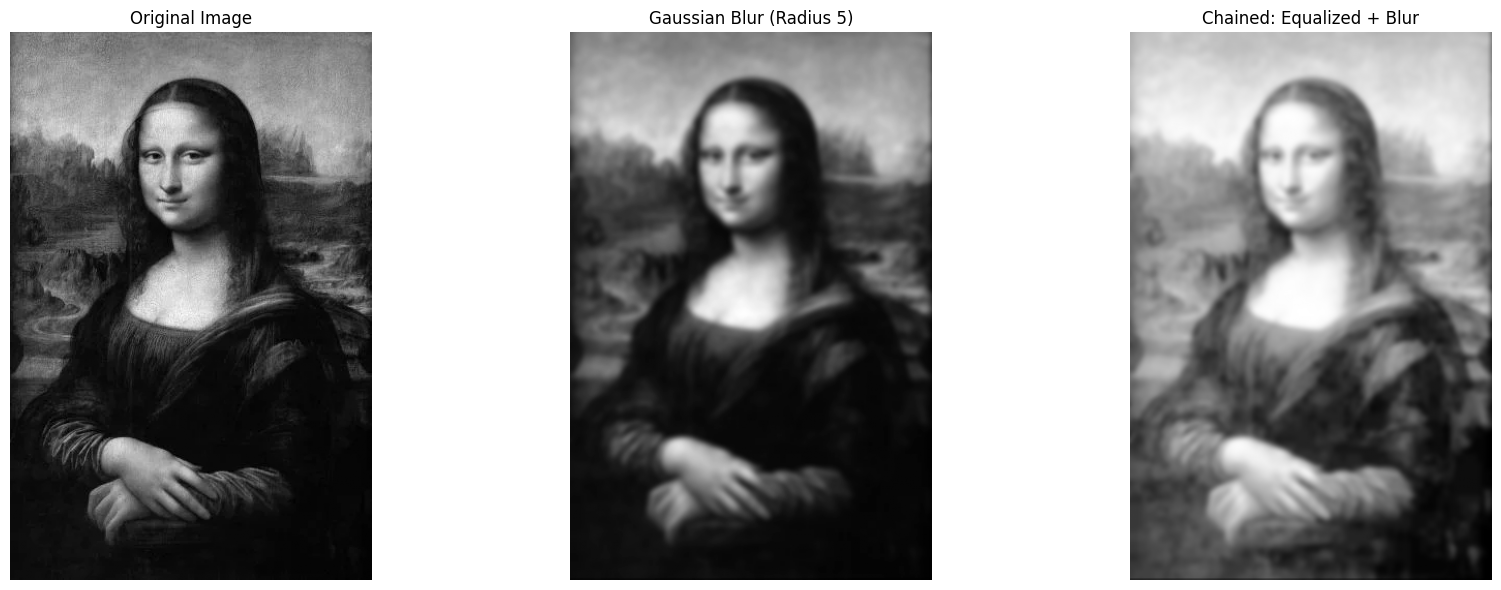

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def load_bin_image(filename):
    with open(filename, 'rb') as f:
        w = np.frombuffer(f.read(4), dtype=np.int32)[0]
        h = np.frombuffer(f.read(4), dtype=np.int32)[0]
        pixels = np.frombuffer(f.read(), dtype=np.uint8)
    return pixels.reshape((h, w))

# Load original and processed data
img_original = load_bin_image('input.bin')
img_blur = load_bin_image('output_blur.bin')
img_chained = load_bin_image('output_chained.bin')

# Plot comparisons side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_original, cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(img_blur, cmap='gray')
axes[1].set_title("Gaussian Blur (Radius 5)")
axes[1].axis('off')

axes[2].imshow(img_chained, cmap='gray')
axes[2].set_title("Chained: Equalized + Blur")
axes[2].axis('off')

plt.tight_layout()
plt.show()